In [1]:
import pandas as pd

train_set = pd.read_csv(r"..\data\train.csv")
train_set.head(5)

,category,text
0,business,iraq to invite phone licence bids iraq is to i...
1,business,malaysia lifts islamic bank limit malaysia s c...
2,tech,hacker threat to apple s itunes users of apple...
3,business,brewers profits lose their fizz heineken and ...
4,entertainment,berlin cheers for anti-nazi film a german movi...


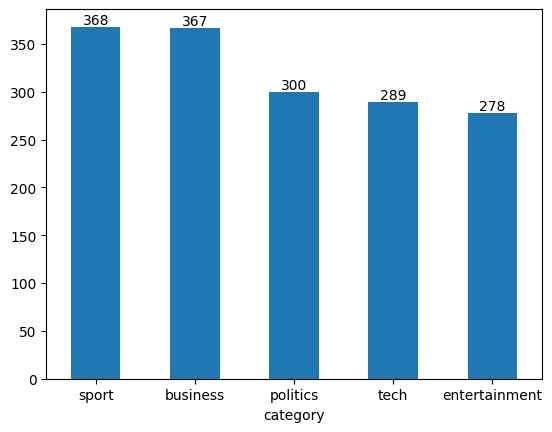

In [6]:
ax = train_set['category'].value_counts().plot.bar(rot=0)

for cont in ax.containers:
    ax.bar_label(cont)

In [8]:
import pandas as pd
import random
from tqdm import tqdm


In [9]:
try:
    from nltk.corpus import wordnet
    import nltk
except:
    !pip install nltk
    from nltk.corpus import wordnet
    import nltk    

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 11.4 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [regex]
   ---------------------------------------- 0/3 [regex]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------

In [10]:
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\brian\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\brian\AppData\Roaming\nltk_data...


True

In [11]:

# ----- Synonym replacement function -----
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(sentence, n=2):
    words = sentence.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if get_synonyms(word)]))
    random.shuffle(random_word_list)
    num_replaced = 0

    for word in random_word_list:
        synonyms = get_synonyms(word)
        if synonyms:
            synonym = random.choice(synonyms)
            new_words = [synonym if w == word else w for w in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return " ".join(new_words)

# ----- Balance dataset -----
def balance_classes(df, target_count=368):
    classes = df['category'].unique()
    balanced_data = []

    for label in classes:
        class_df = df[df['category'] == label]
        current_count = len(class_df)
        balanced_data.append(class_df)

        # If class needs augmentation
        if current_count < target_count:
            needed = target_count - current_count
            samples = class_df['text'].tolist()

            augmented_texts = []
            for i in range(needed):
                original_text = random.choice(samples)
                aug_text = synonym_replacement(original_text, n=2)
                augmented_texts.append([aug_text, label])

            aug_df = pd.DataFrame(augmented_texts, columns=['text', 'category'])
            balanced_data.append(aug_df)

    return pd.concat(balanced_data).reset_index(drop=True)

# ========== MAIN ==========
input_file = r"..\data\train.csv"   # Your input CSV with 'text' and 'label'
output_file = r"..\data\augmented.csv"

df = pd.read_csv(input_file)
print("Original class distribution:\n", df['category'].value_counts())

balanced_df = balance_classes(df, target_count=368)

print("New class distribution:\n", balanced_df['category'].value_counts())
balanced_df.to_csv(output_file, index=False)
print(f"Balanced dataset saved to: {output_file}")


Original class distribution:
 category
sport            368
business         367
politics         300
tech             289
entertainment    278
Name: count, dtype: int64
New class distribution:
 category
business         368
tech             368
entertainment    368
politics         368
sport            368
Name: count, dtype: int64
Balanced dataset saved to: ..\data\augmented.csv
